# Exercise 2 — ML Key Challenges


In this exercise, you will train several models and observe three cases:

1. Underfitting — model too simple
2. Good fit — model captures the pattern
3. Overfitting — model memorizes the noise

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


Create synthetic nonlinear data

In [3]:
np.random.seed(42)

X = np.linspace(0, 10, 80).reshape(-1, 1)

y_true = np.sin(X).ravel()

y = y_true + np.random.normal(0, 0.25, size=y_true.shape)


Train / test split

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# For smooth plotting
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

In [5]:
models = [
    {"degree": 1, "name": "Model A"},
    {"degree": 4, "name": "Model B"},
    {"degree": 15, "name": "Model C"},
]

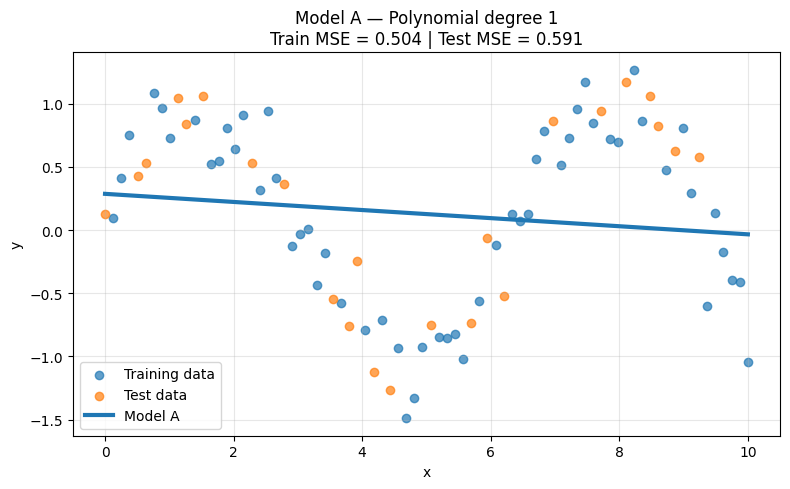

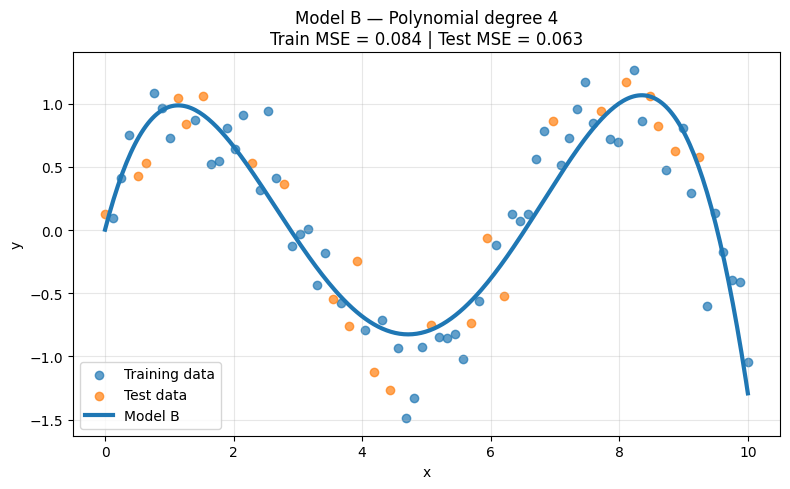

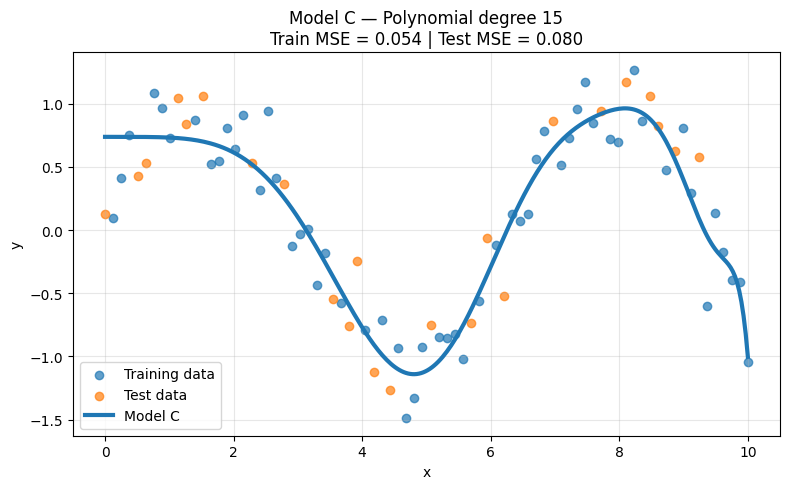

In [6]:
for item in models:
    degree = item["degree"]

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot = model.predict(x_plot)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    plt.figure(figsize=(8, 5))

    plt.scatter(X_train, y_train, alpha=0.7, label="Training data")
    plt.scatter(X_test, y_test, alpha=0.7, label="Test data")
    plt.plot(x_plot, y_plot, linewidth=3, label=item["name"])

    plt.title(
        f"{item['name']} — Polynomial degree {degree}\n"
        f"Train MSE = {train_mse:.3f} | Test MSE = {test_mse:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Questions

1. Which model is underfitting?
2. Which model is overfitting?
3. Which model generalizes best?
4. How do you know from the plot?
5. How do you know from the train/test MSE?

## Answer

1, The model A is underfitting

2, The model C is overfitting

3, Model B is the most balance/ generalize best

4, 
- The Modal A is considered as underfitting when it appear a linear line, result in ignoring those important datas. 
- The Model C is overfitting when its line try to capture the noises around instead of really recognize the real pattern.
- The model B, this is the best fit because it follows the natural curvature of the data points without becoming overly jagged or sensitive to individual points.

5, 
    We can see that in the model A, MSE is large(MSE = 0.504 and MSE = 0.591), it perform poorly on everything beacause it hasn't learned the pattern yet.
In the model B, both test and train MSE are low and it closed to each other(MSE = 0.084 and MSE = 0.063) and the train is bigger but the test one is smaller and near 0.
In the model C, train MSE is low and test is high(MSE = 0.054 and MSE = 0.080) and the test is quite far from 0.